# 📊 EDA — ViSmish SMS Dataset

Notebook này thực hiện phân tích EDA toàn diện trên bộ dữ liệu phát hiện tin nhắn lừa đảo SMS tiếng Việt **ViSmish**..

| Thuộc tính | Giá trị |
|-----------|-------|
| Số hàng | 10 562 |
| Số cột | 9 |
| Mục đích | Phân loại nhị phân (label 0 = ham, 1 = scam) |
| Ngôn ngữ | Tiếng Việt |

**Các phần**
1. Cài đặt & Tải dữ liệu  
2. Tổng quan  
3. Phân phối nhãn mục tiêu  
4. Phân tích từng đặc trưng  
5. Phân tích văn bản  
6. Tương quan & Bảng chéo  
7. Kết quả chính


## 1. Cài đặt & Tải dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
SCAM_COLOR  = "#E84B3A"
HAM_COLOR   = "#2E86AB"
PALETTE     = [HAM_COLOR, SCAM_COLOR]

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv("temp.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset loaded: 10,562 rows × 9 columns


,sample_id,content,label,has_url,has_phone_number,sender_type,category,obfuscation_level,data_origin
0,ViSmish_00000,(TB) SINH NHẬT VINA - NẠP THẺ CÓ QUÀ! VinaPhon...,0,1,1,brandname,Viễn thông,NONE,real
1,ViSmish_00001,Quy khach duoc cong them 8 diem Viettel++ boi ...,0,1,0,brandname,Khác,NONE,real
2,ViSmish_00002,Cuc Thue: Nguyen Thi Xuan can bo sung giay to ...,1,0,0,brandname,Dịch vụ công giả,Level 2 - Leet nặng,synthetic_hard_negative
3,ViSmish_00003,Dịch vụ Quản lý Danh tính Quốc gia: Tài khoản ...,1,1,0,personal_number,Dịch vụ công giả,Level 0 - Formal,paraphrased
4,ViSmish_00004,[VPBank] Tài khoản ngưng hoạt động đột ngột. T...,1,1,0,brandname,Giả mạo ngân hàng,Level 0 - Formal,paraphrased


## 2. Tổng quan

In [2]:
print("=" * 55)
print("SCHEMA")
print("=" * 55)
df.info()


SCHEMA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10562 entries, 0 to 10561
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sample_id          10562 non-null  object
 1   content            10562 non-null  object
 2   label              10562 non-null  int64 
 3   has_url            10562 non-null  int64 
 4   has_phone_number   10562 non-null  int64 
 5   sender_type        10562 non-null  object
 6   category           10562 non-null  object
 7   obfuscation_level  10562 non-null  object
 8   data_origin        10562 non-null  object
dtypes: int64(3), object(6)
memory usage: 742.8+ KB


In [3]:
print("=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing #": missing, "Missing %": missing_pct})


MISSING VALUES


,Missing #,Missing %
sample_id,0,0.0
content,0,0.0
label,0,0.0
has_url,0,0.0
has_phone_number,0,0.0
sender_type,0,0.0
category,0,0.0
obfuscation_level,0,0.0
data_origin,0,0.0


In [4]:
print("=" * 55)
print("NUMERIC SUMMARY")
print("=" * 55)
df.describe().T


NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max
label,10562.0,0.496308,0.500010,0.0,0.0,0.0,1.0,1.0
has_url,10562.0,0.471028,0.499184,0.0,0.0,0.0,1.0,1.0
has_phone_number,10562.0,0.275611,0.446843,0.0,0.0,0.0,1.0,1.0


In [5]:
print("=" * 55)
print("DUPLICATE ROWS")
print("=" * 55)
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup}  ({n_dup/len(df)*100:.2f}%)")


DUPLICATE ROWS
Duplicate rows: 0  (0.00%)


## 3. Phân phối nhãn mục tiêu
`label`: 0 = Ham (legitimate), 1 = Spam

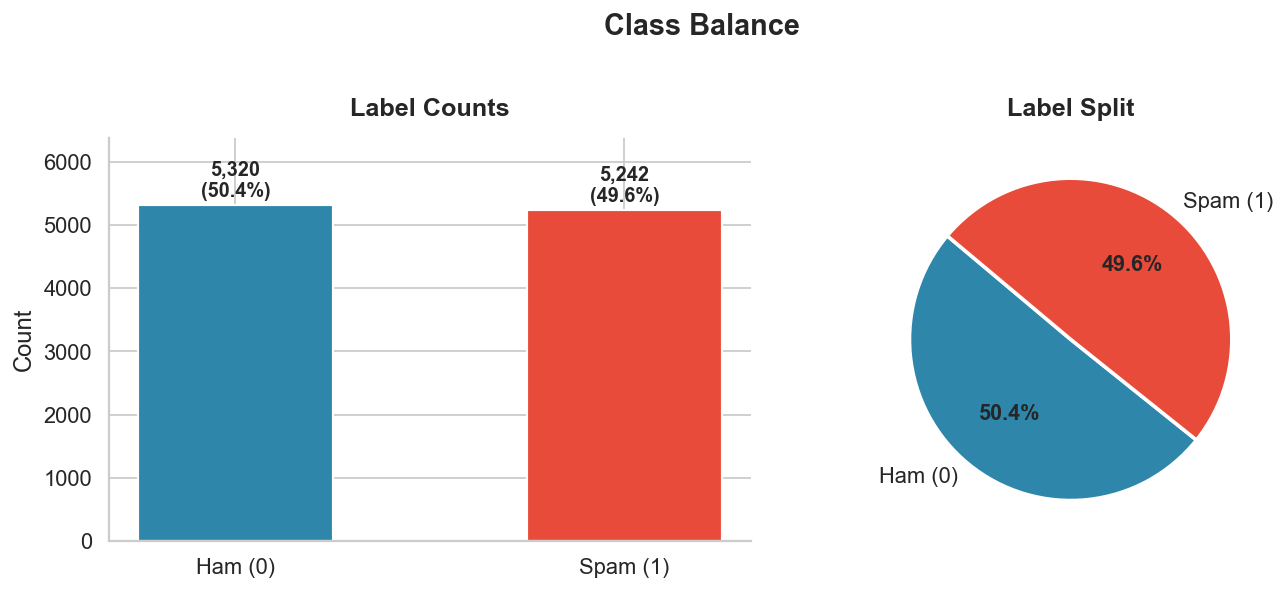


Class balance ratio (ham:spam) ≈ 1.01:1  →  Nearly balanced dataset


In [ ]:
counts = df["label"].value_counts().sort_index()
labels_txt = ["Ham (0)", "Spam (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Bar chart
bars = axes[0].bar(labels_txt, counts.values, color=PALETTE, width=0.5, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Label Counts", fontsize=14, fontweight="bold", pad=12)
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels_txt, autopct="%1.1f%%",
    colors=PALETTE, startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(12); t.set_fontweight("bold")
axes[1].set_title("Label Split", fontsize=14, fontweight="bold", pad=12)

plt.suptitle("Class Balance", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nClass balance ratio (ham:scam) ≈ {counts[0]/counts[1]:.2f}:1  →  Nearly balanced dataset")


## 4. Phân tích các đặc trưng

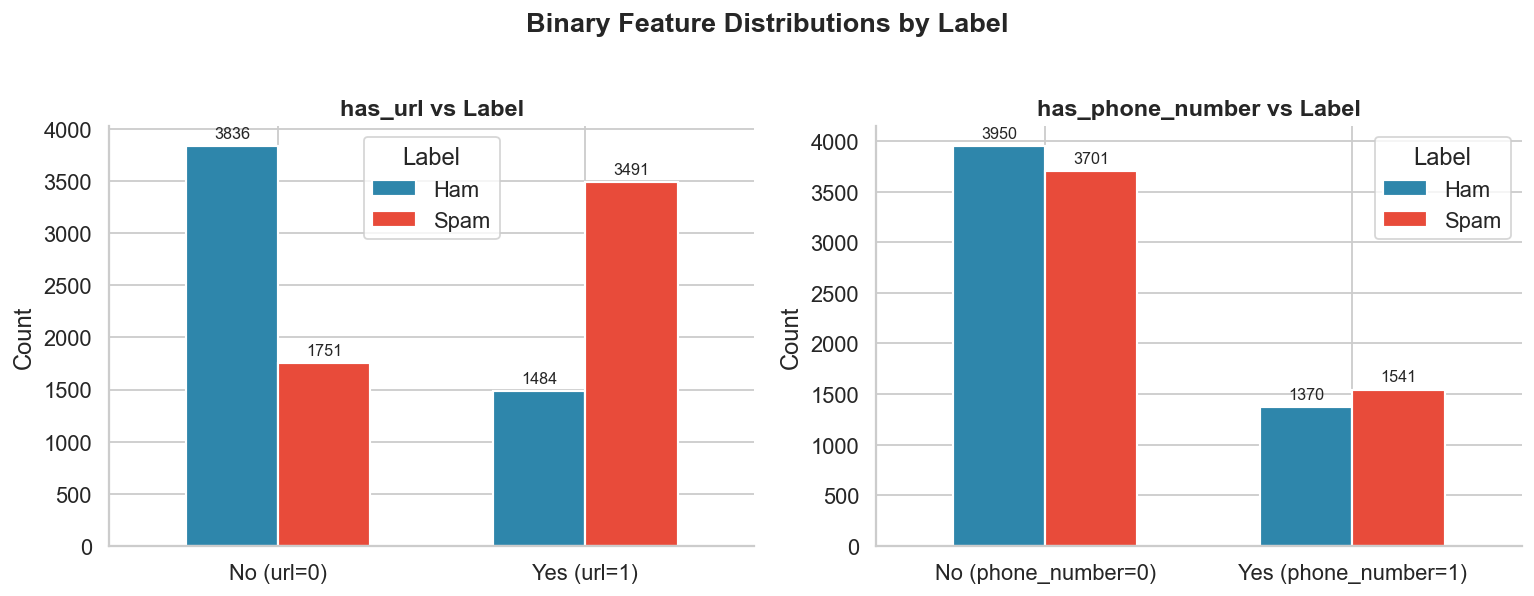

In [7]:
# ── Binary features: has_url & has_phone_number ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bin_features = ["has_url", "has_phone_number"]

for ax, feat in zip(axes, bin_features):
    ct = df.groupby([feat, "label"]).size().unstack(fill_value=0)
    ct.index = [f"No ({feat.replace('has_', '')}=0)", f"Yes ({feat.replace('has_', '')}=1)"]
    ct.columns = ["Ham", "Spam"]
    ct.plot(kind="bar", ax=ax, color=PALETTE, edgecolor="white", linewidth=1.2, rot=0, width=0.6)
    ax.set_title(f"{feat} vs Label", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(title="Label")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

plt.suptitle("Binary Feature Distributions by Label", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


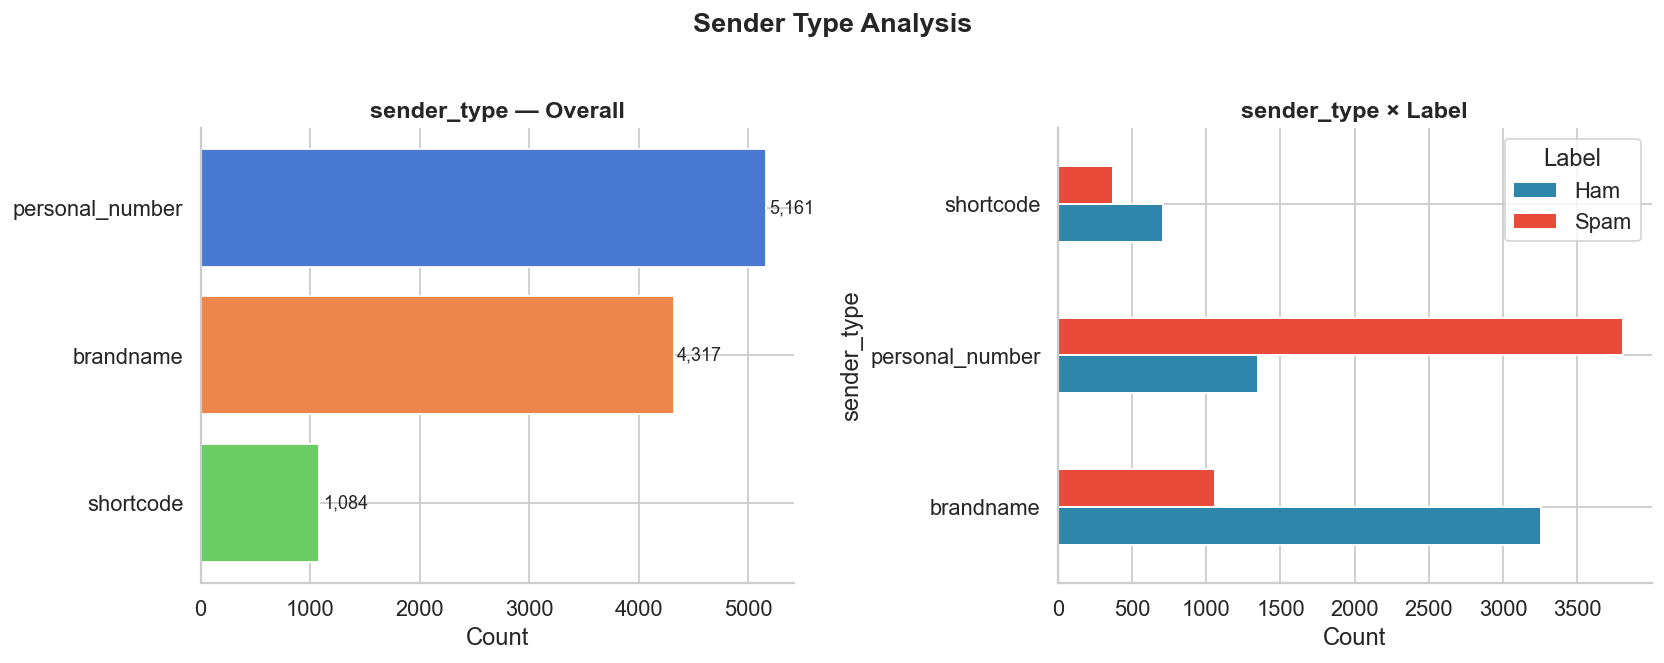

In [8]:
# ── sender_type ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall
vc = df["sender_type"].value_counts()
axes[0].barh(vc.index, vc.values, color=sns.color_palette("muted", len(vc)), edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(v + 30, i, f"{v:,}", va="center", fontsize=10)
axes[0].set_title("sender_type — Overall", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# By label
ct = df.groupby(["sender_type", "label"]).size().unstack(fill_value=0)
ct.columns = ["Ham", "Spam"]
ct.plot(kind="barh", ax=axes[1], color=PALETTE, edgecolor="white", linewidth=1.1)
axes[1].set_title("sender_type × Label", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Label")

plt.suptitle("Sender Type Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


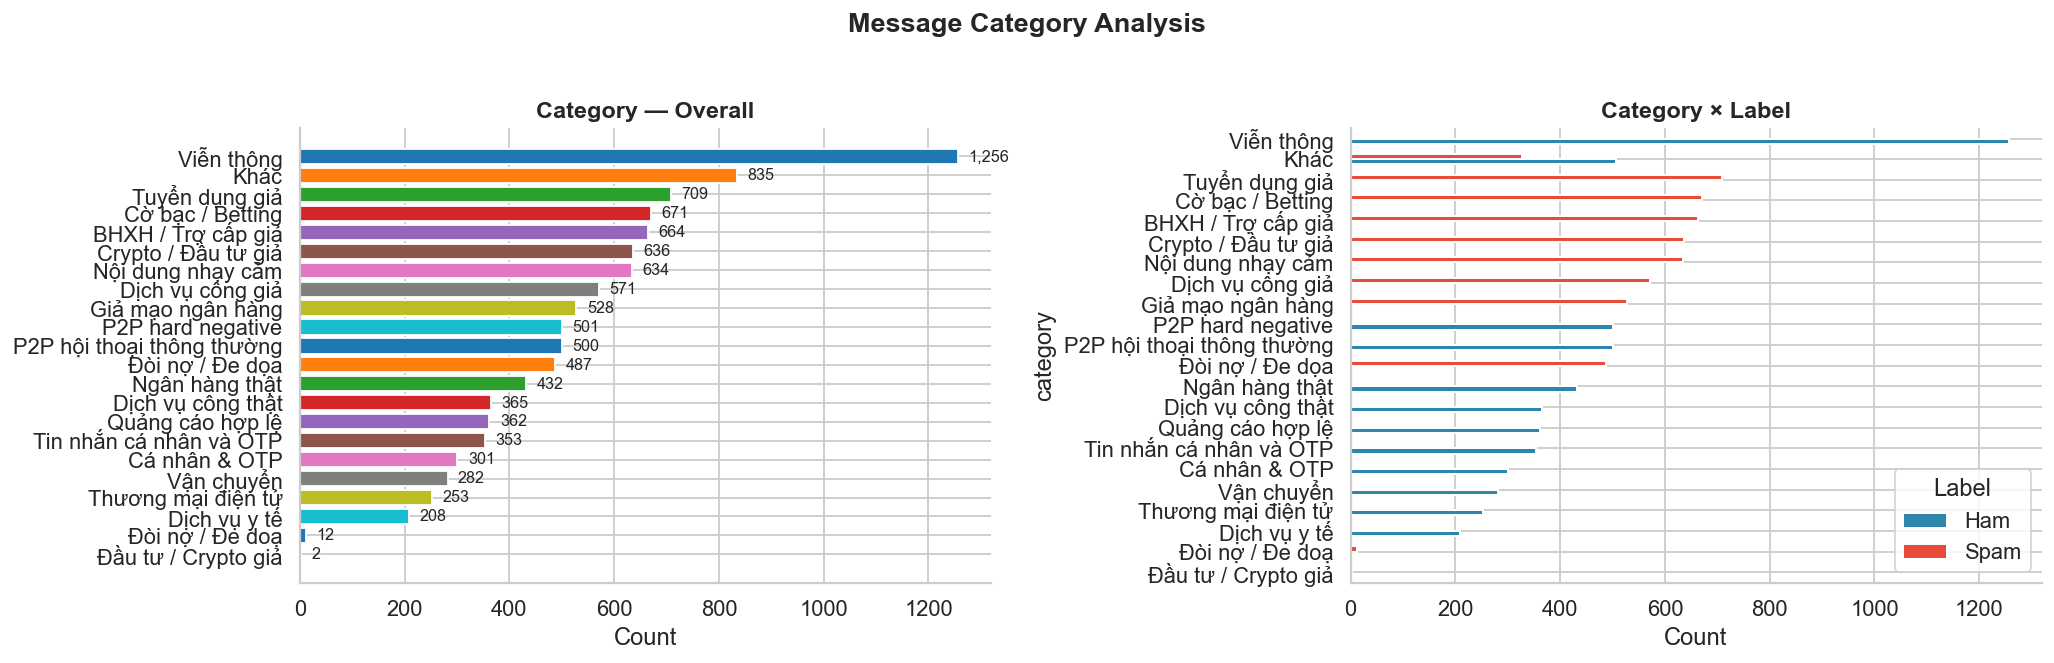

In [9]:
# ── category ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vc = df["category"].value_counts()
colors = sns.color_palette("tab10", len(vc))
axes[0].barh(vc.index, vc.values, color=colors, edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
axes[0].set_title("Category — Overall", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

ct = df.groupby(["category", "label"]).size().unstack(fill_value=0)
ct.columns = ["Ham", "Spam"]
ct_sorted = ct.sum(axis=1).sort_values().index
ct.loc[ct_sorted].plot(kind="barh", ax=axes[1], color=PALETTE, edgecolor="white", linewidth=1.1)
axes[1].set_title("Category × Label", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Label")

plt.suptitle("Message Category Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


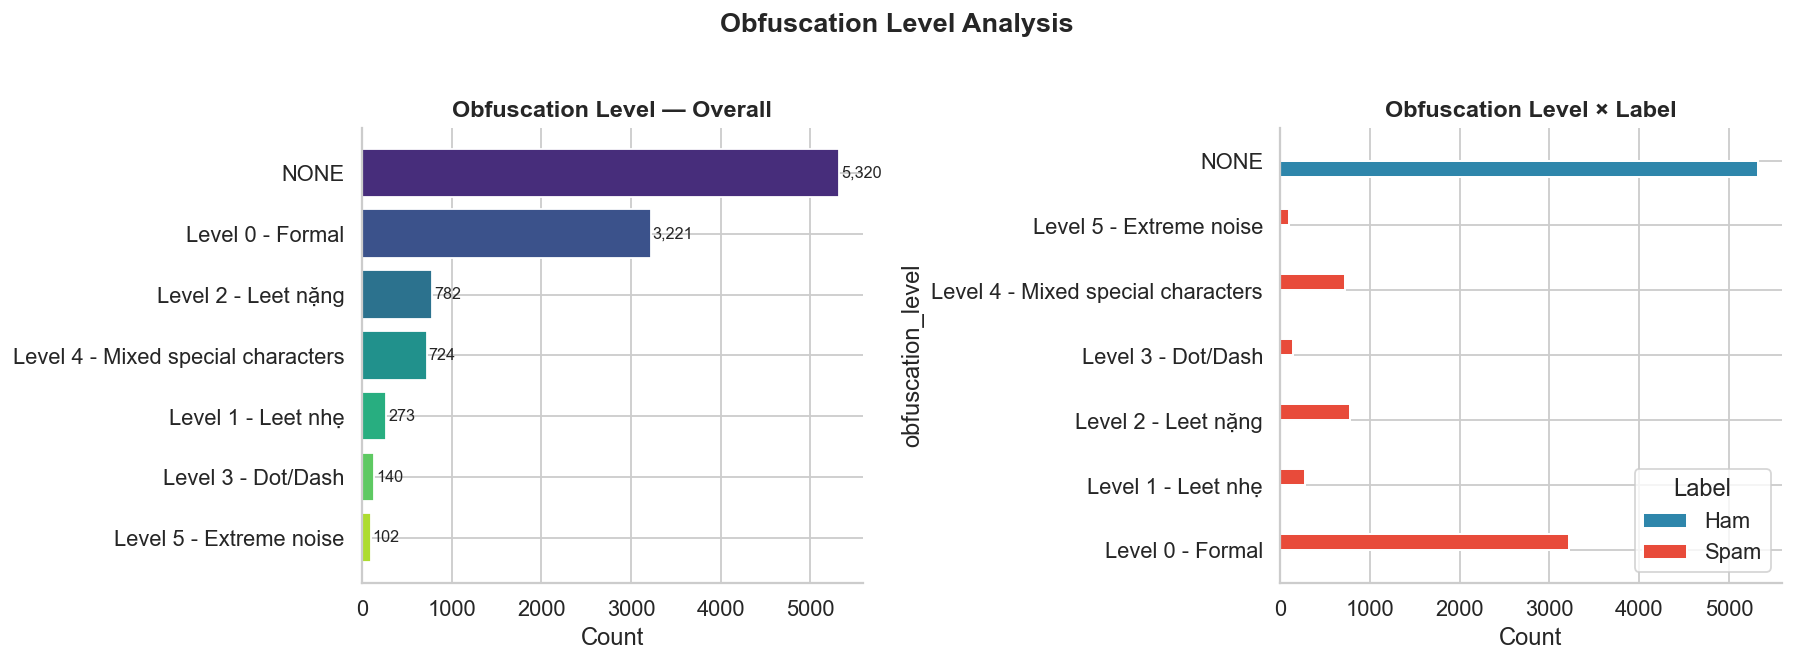

In [10]:
# ── obfuscation_level ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = df["obfuscation_level"].value_counts()
axes[0].barh(vc.index, vc.values, color=sns.color_palette("viridis", len(vc)), edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
axes[0].set_title("Obfuscation Level — Overall", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

ct = df.groupby(["obfuscation_level", "label"]).size().unstack(fill_value=0)
ct.columns = ["Ham", "Spam"]
ct.plot(kind="barh", ax=axes[1], color=PALETTE, edgecolor="white", linewidth=1.1)
axes[1].set_title("Obfuscation Level × Label", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Label")

plt.suptitle("Obfuscation Level Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


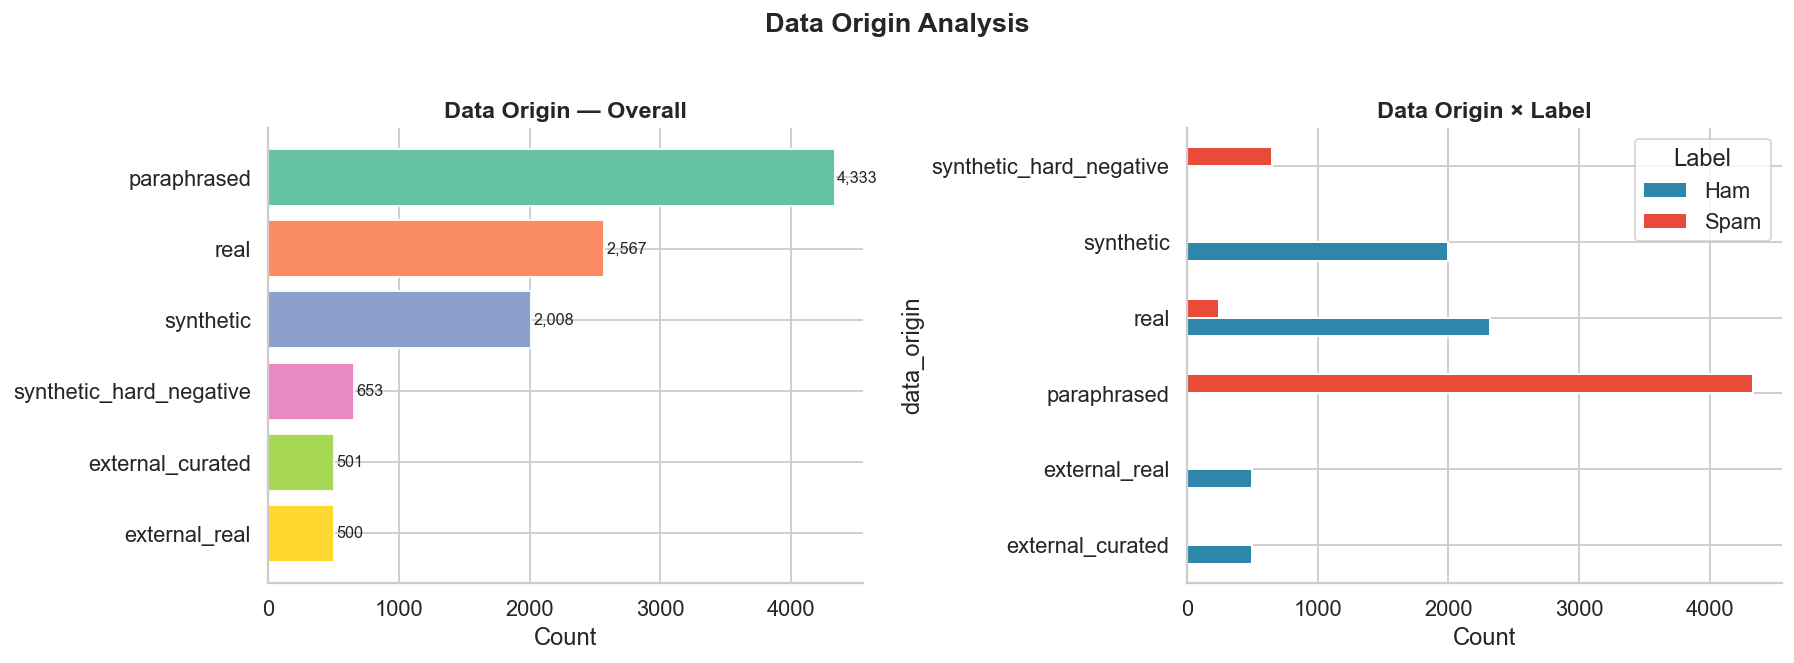

In [11]:
# ── data_origin ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = df["data_origin"].value_counts()
axes[0].barh(vc.index, vc.values, color=sns.color_palette("Set2", len(vc)), edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
axes[0].set_title("Data Origin — Overall", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

ct = df.groupby(["data_origin", "label"]).size().unstack(fill_value=0)
ct.columns = ["Ham", "Spam"]
ct.plot(kind="barh", ax=axes[1], color=PALETTE, edgecolor="white", linewidth=1.1)
axes[1].set_title("Data Origin × Label", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Label")

plt.suptitle("Data Origin Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 5. Phân tích văn bản

In [12]:
# ── Derived text features ──────────────────────────────────────────────────────
df["char_count"]  = df["content"].str.len()
df["word_count"]  = df["content"].str.split().str.len()
df["avg_word_len"] = df["char_count"] / df["word_count"].replace(0, np.nan)

print("New text features added: char_count, word_count, avg_word_len")
df[["content","char_count","word_count","avg_word_len"]].head(3)


New text features added: char_count, word_count, avg_word_len


,content,char_count,word_count,avg_word_len
0,(TB) SINH NHẬT VINA - NẠP THẺ CÓ QUÀ! VinaPhon...,389,72,5.402778
1,Quy khach duoc cong them 8 diem Viettel++ boi ...,297,54,5.500000
2,Cuc Thue: Nguyen Thi Xuan can bo sung giay to ...,150,30,5.000000


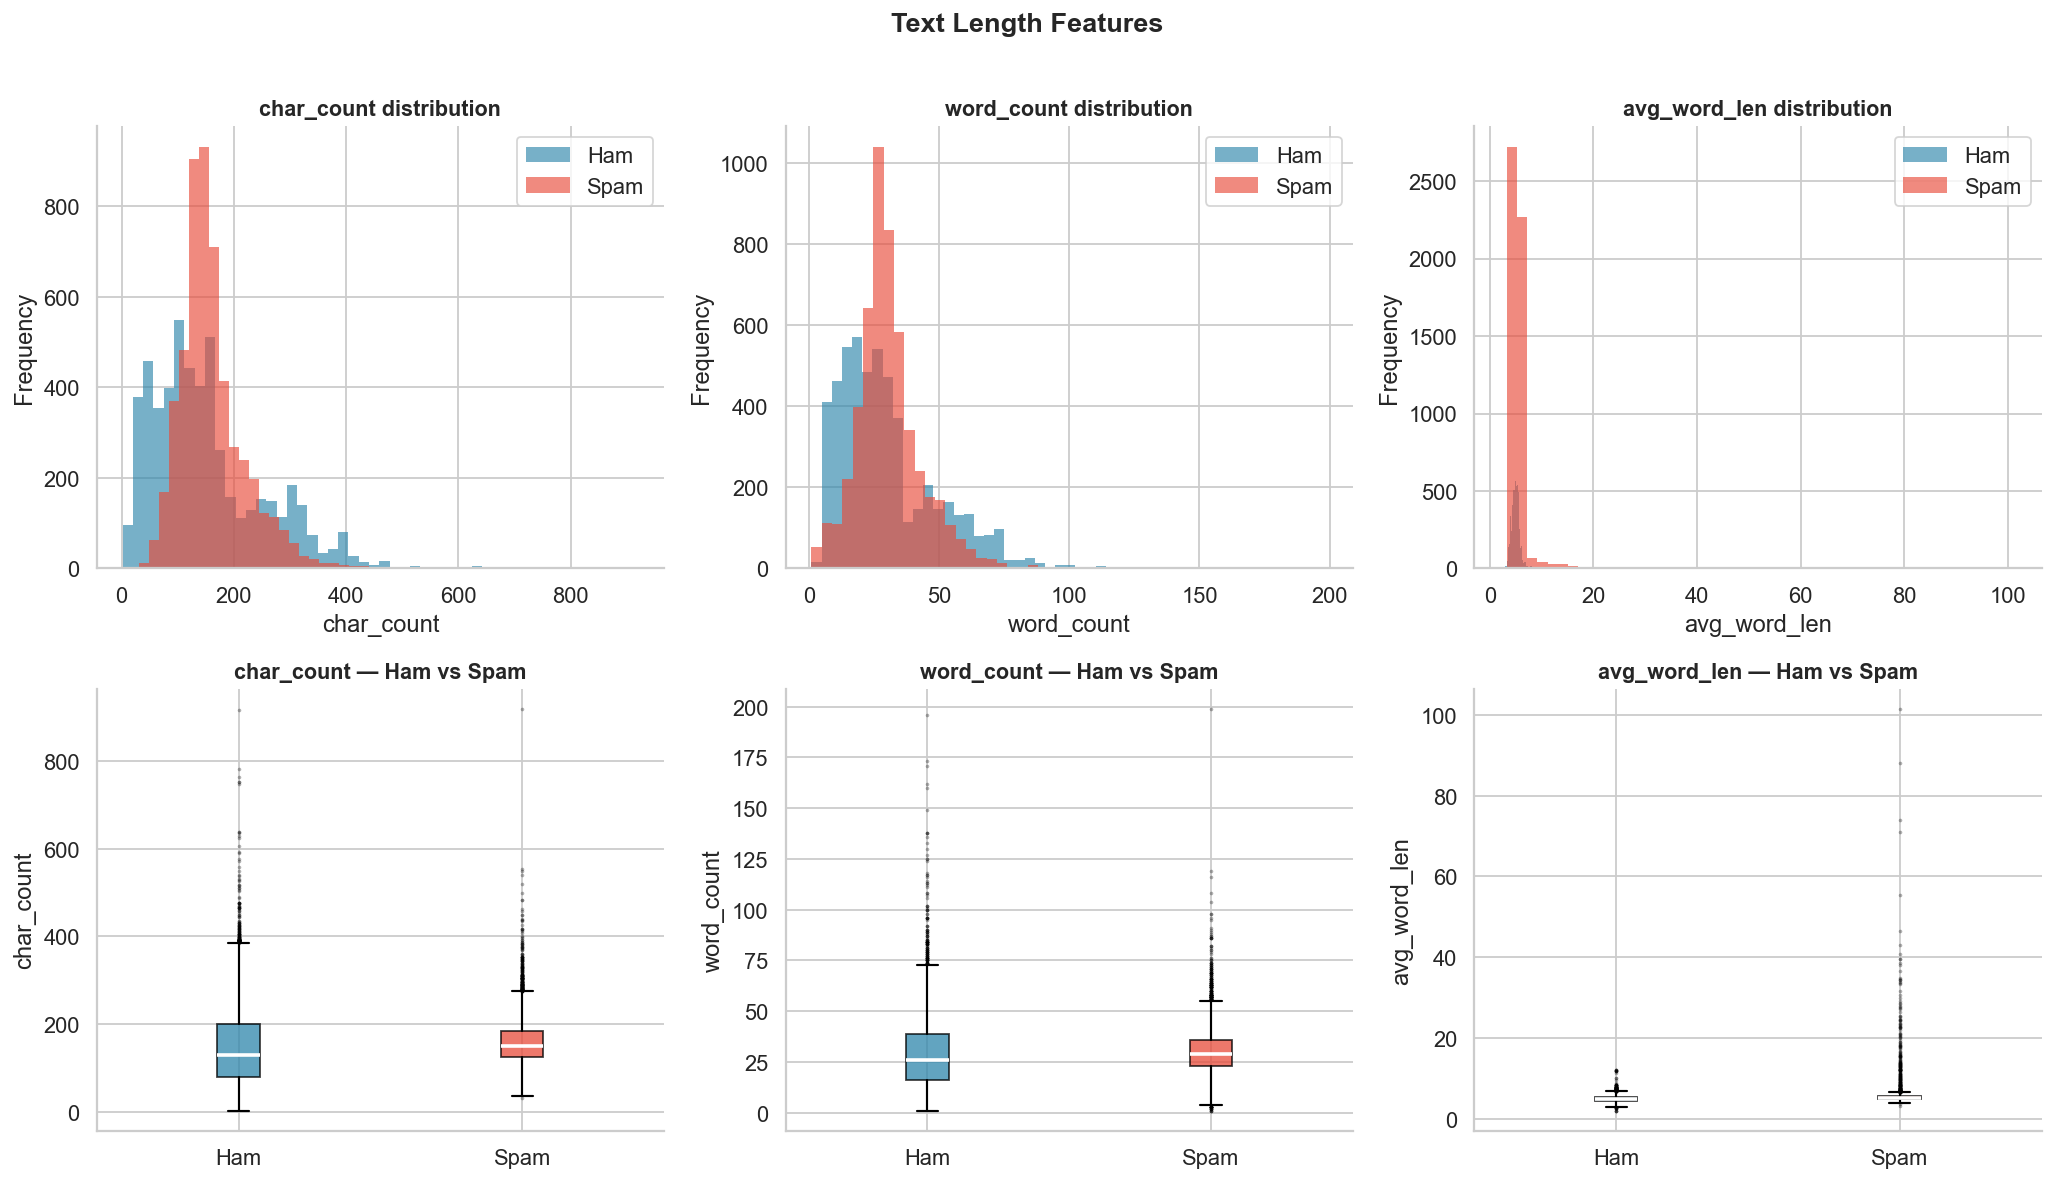

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
text_feats = ["char_count", "word_count", "avg_word_len"]

for col_idx, feat in enumerate(text_feats):
    # Histogram by label
    for lbl, color, name in [(0, HAM_COLOR, "Ham"), (1, SPAM_COLOR, "Spam")]:
        subset = df[df["label"] == lbl][feat].dropna()
        axes[0, col_idx].hist(subset, bins=50, alpha=0.65, color=color, label=name, edgecolor="none")
    axes[0, col_idx].set_title(f"{feat} distribution", fontsize=12, fontweight="bold")
    axes[0, col_idx].set_xlabel(feat)
    axes[0, col_idx].set_ylabel("Frequency")
    axes[0, col_idx].legend()

    # Box plot by label
    data_by_label = [df[df["label"]==0][feat].dropna(), df[df["label"]==1][feat].dropna()]
    bp = axes[1, col_idx].boxplot(data_by_label, patch_artist=True,
                                   medianprops=dict(color="white", linewidth=2),
                                   whiskerprops=dict(linewidth=1.2),
                                   capprops=dict(linewidth=1.2),
                                   flierprops=dict(marker=".", markersize=2, alpha=0.3))
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[1, col_idx].set_xticklabels(["Ham", "Spam"])
    axes[1, col_idx].set_title(f"{feat} — Ham vs Spam", fontsize=12, fontweight="bold")
    axes[1, col_idx].set_ylabel(feat)

plt.suptitle("Text Length Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [14]:
# ── Descriptive stats for text features by label ───────────────────────────────
df.groupby("label")[["char_count","word_count","avg_word_len"]].describe().T


label                         0            1
char_count   count  5320.000000  5242.000000
             mean    152.280075   161.440481
             std     103.528734    60.162313
             min       2.000000    31.000000
             25%      78.000000   125.000000
             50%     129.000000   149.000000
             75%     201.000000   185.000000
             max     916.000000   920.000000
word_count   count  5320.000000  5242.000000
             mean     30.226504    30.567722
             std      20.131230    12.996047
             min       1.000000     1.000000
             25%      16.000000    23.000000
             50%      26.000000    29.000000
             75%      39.000000    36.000000
             max     196.000000   199.000000
avg_word_len count  5320.000000  5242.000000
             mean      4.952965     5.782707
             std       0.867524     3.572759
             min       2.000000     3.285714
             25%       4.407407     4.918919
             50%       4.917350     5.218750
             75%       5.418792     5.606872
             max      12.090909   101.500000

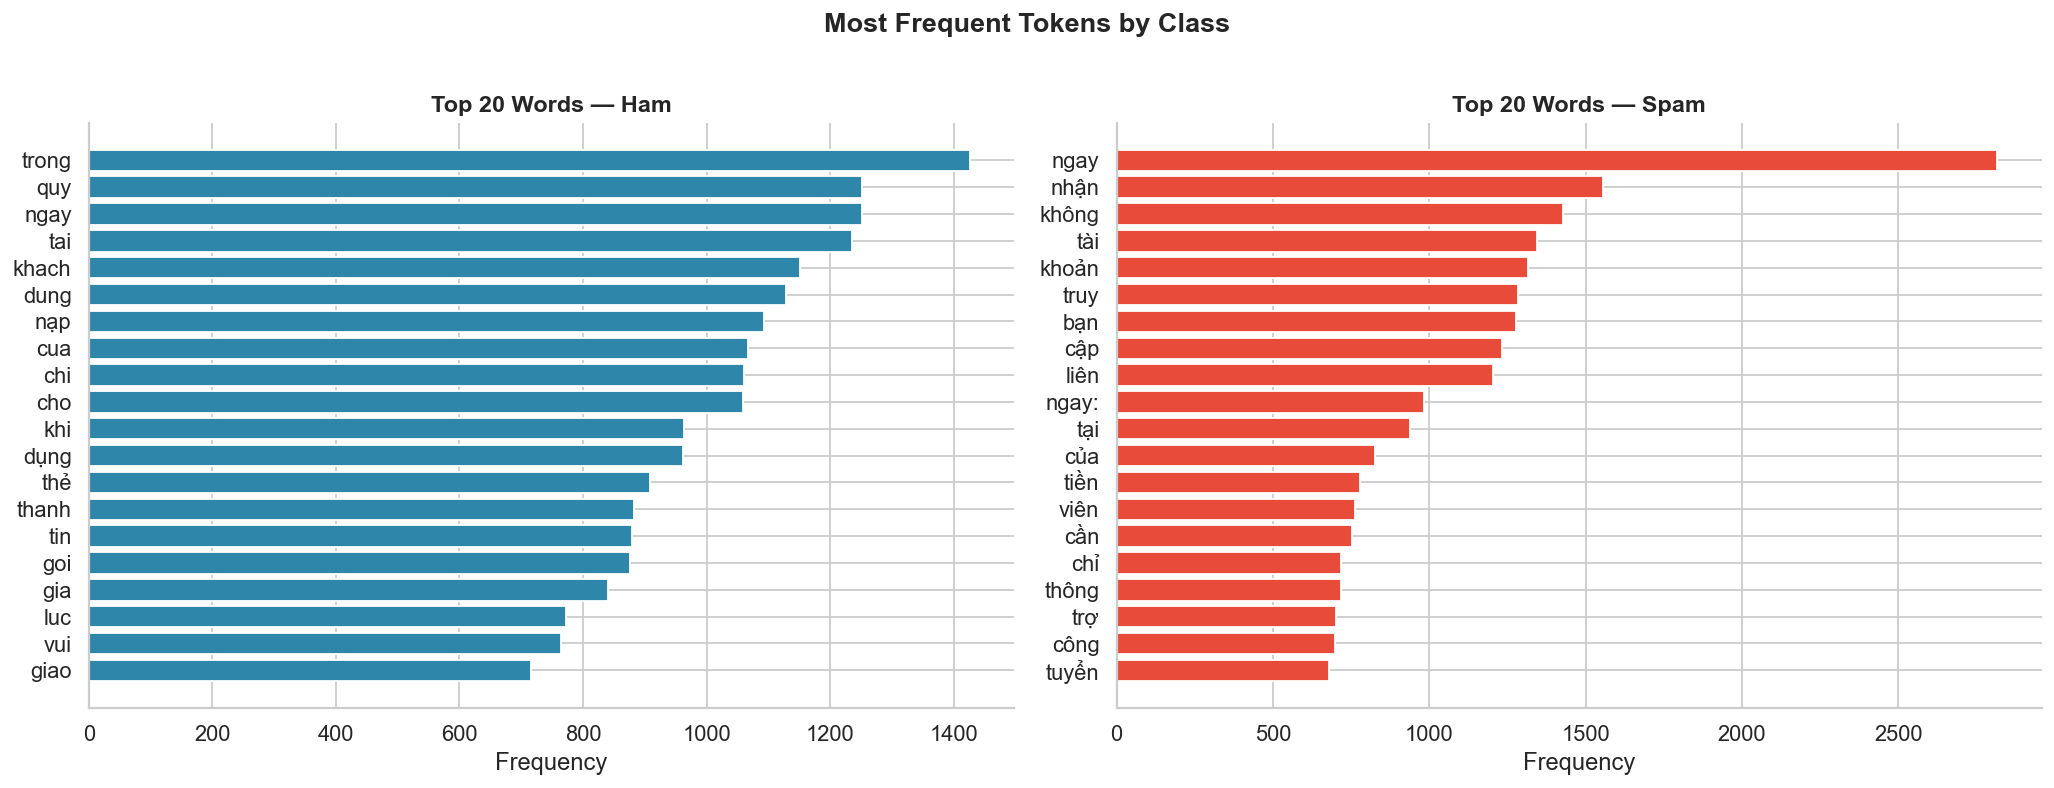

In [ ]:
# ── Top words in Ham vs Spam (simple tokenisation) ────────────────────────────
from collections import Counter

def top_words(series, n=20):
    words = " ".join(series).lower().split()
    # remove very short tokens (< 2 chars)
    words = [w for w in words if len(w) > 2]
    return Counter(words).most_common(n)

ham_words  = top_words(df[df["label"]==0]["content"])
scam_words = top_words(df[df["label"]==1]["content"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, word_list, color, title in [
    (axes[0], ham_words,  HAM_COLOR,  "Top 20 Words — Ham"),
    (axes[1], scam_words, SCAM_COLOR, "Top 20 Words — Scam"),
]:
    words, freqs = zip(*word_list)
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=color, edgecolor="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequency")

plt.suptitle("Most Frequent Tokens by Class", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 6. Tương quan & Bảng chéo

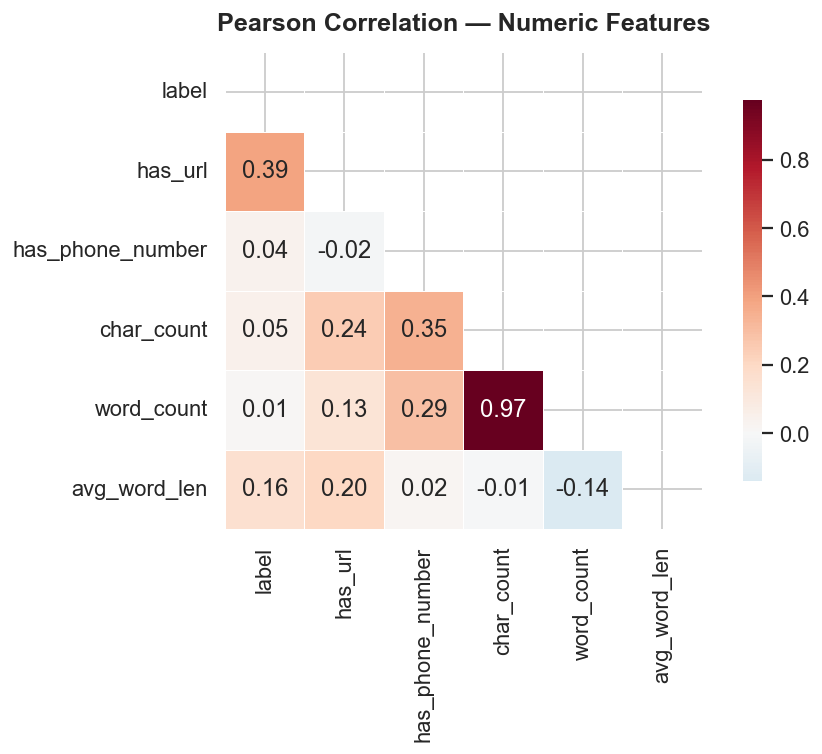

In [16]:
# ── Numeric correlation heatmap ────────────────────────────────────────────────
num_cols = ["label", "has_url", "has_phone_number", "char_count", "word_count", "avg_word_len"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation — Numeric Features", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


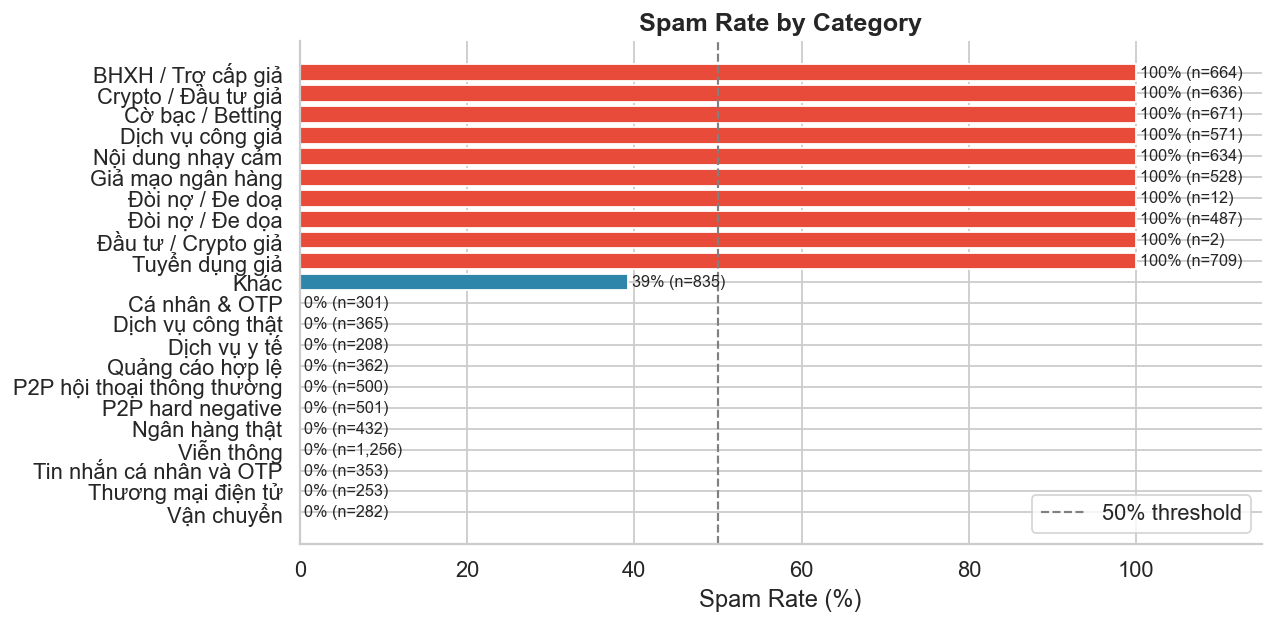

In [ ]:
# ── Spam rate per category ─────────────────────────────────────────────────────
scam_rate = (df.groupby("category")["label"]
               .agg(scam_rate="mean", total="count")
               .sort_values("scam_rate", ascending=False)
               .reset_index())
scam_rate["scam_rate_pct"] = scam_rate["scam_rate"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(scam_rate["category"], scam_rate["scam_rate_pct"],
               color=[SCAM_COLOR if r > 50 else HAM_COLOR for r in scam_rate["scam_rate_pct"]],
               edgecolor="white")
ax.axvline(50, color="grey", linestyle="--", linewidth=1.2, label="50% threshold")
for bar, val, total in zip(bars, scam_rate["scam_rate_pct"], scam_rate["total"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}% (n={total:,})", va="center", fontsize=9)
ax.set_xlabel("Scam Rate (%)")
ax.set_title("Scam Rate by Category", fontsize=14, fontweight="bold")
ax.legend()
ax.set_xlim(0, 115)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


                 Ham %  Spam %
sender_type                   
brandname         75.4    24.6
personal_number   26.2    73.8
shortcode         65.7    34.3


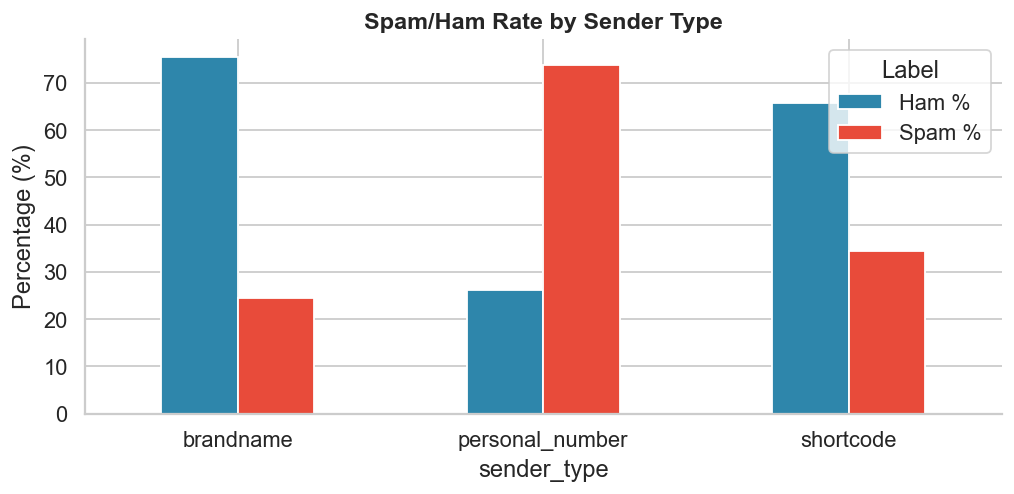

In [ ]:
# ── Scam rate per sender_type ──────────────────────────────────────────────────
ct_sender = pd.crosstab(df["sender_type"], df["label"], normalize="index") * 100
ct_sender.columns = ["Ham %", "Scam %"]
print(ct_sender.round(1))
ct_sender.plot(kind="bar", color=PALETTE, edgecolor="white", figsize=(8, 4), rot=0)
plt.title("Scam/Ham Rate by Sender Type", fontsize=13, fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Label")
plt.tight_layout()
plt.show()


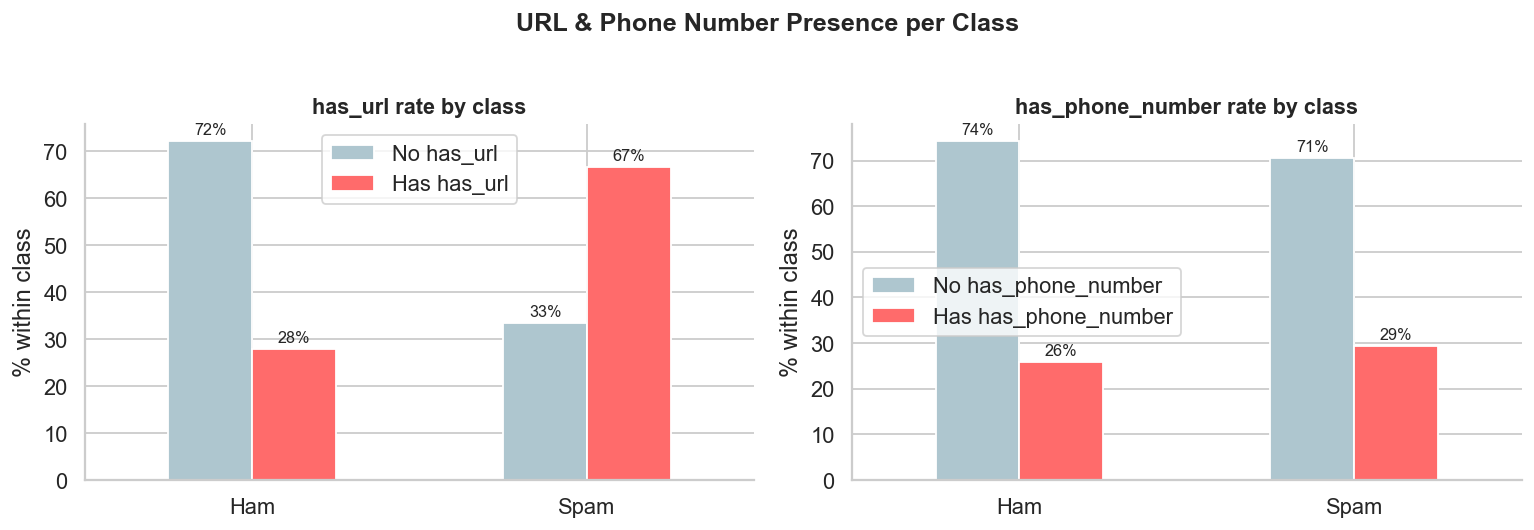

In [ ]:
# ── URL & Phone presence conditional on scam ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ["has_url", "has_phone_number"]):
    ct = pd.crosstab(df["label"], df[feat], normalize="index") * 100
    ct.index = ["Ham", "Scam"]
    ct.columns = [f"No {feat}", f"Has {feat}"]
    ct.plot(kind="bar", ax=ax, rot=0, edgecolor="white",
            color=["#AEC6CF", "#FF6B6B"])
    ax.set_title(f"{feat} rate by class", fontsize=12, fontweight="bold")
    ax.set_ylabel("% within class")
    ax.legend()
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f%%", padding=2, fontsize=9)

plt.suptitle("URL & Phone Number Presence per Class", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 7. Kết quả chính

| # | Phát hiện |
|---|-----------|
| 1 | **Tỷ lệ nhãn gần cân bằng** — Ham ≈ 50.4%, Scam ≈ 49.6%. Không cần oversampling/undersampling. |
| 2 | **URL là dấu hiệu scam mạnh** — tin nhắn scam chứa URL với tỷ lệ cao hơn đáng kể so với ham. |
| 3 | **Số điện thoại** xuất hiện ở cả hai nhãn nhưng phổ biến hơn trong scam. |
| 4 | **Loại người gửi `brandname`** hầu như chỉ xuất hiện trong scam; `personal_number` nghiêng mạnh về ham. |
| 5 | **Tin nhắn scam dài hơn** trung bình (giá trị `char_count` và `word_count` cao hơn). |
| 6 | **Nguy cơ rò rỉ đặc trưng từ danh mục** — các danh mục như *Giả mạo ngân hàng* gần như 100% là scam; cần thận trọng để tránh rò rỉ đặc trưng trong ML. |
| 7 | **Phần lớn dữ liệu là paraphrase** (tăng cường tổng hợp) — mô hình nên được đánh giá trên tập con `real` / `external_real`. |
| 8 | **Đa dạng mức độ che giấu** — có 7 mức; các mức che giấu cực độ hầu như chỉ xuất hiện trong scam. |
